# Lecture 17 - Exercise - Explore the Ia Supernova dataset

In [76]:
#-------------------------------------------------------------------------
# importing libraries and setting up nice plots
#-------------------------------------------------------------------------

import os
import corner
import emcee
import numpy                        as np
import matplotlib.pyplot            as plt
import matplotlib                   as mpl
from   matplotlib                   import rc
from   mycolorpy                    import colorlist as mcp
from   sys                          import stdout
from   scipy                        import stats, integrate, special
from   astroML                      import stats as astroMLstats
from   astroML.datasets             import generate_mu_z
from   astroML.linear_model         import LinearRegression, PolynomialRegression, BasisFunctionRegression
from   astropy.visualization.hist   import hist  as fancyhist
from   astropy.cosmology            import Planck15
from   sklearn.neighbors            import KernelDensity
from   sklearn.manifold             import Isomap, TSNE
from   sklearn.cluster              import KMeans
from   sklearn.neighbors            import KNeighborsClassifier
from   sklearn.metrics              import confusion_matrix, accuracy_score
from   sklearn.model_selection      import train_test_split, learning_curve, GridSearchCV
from   sklearn.mixture              import GaussianMixture
from   sklearn.decomposition        import PCA, NMF, FastICA
# from   sklearn.linear_model         import LogisticRegression, LinearRegression


#-------------------------------------------------------------------------

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif" : ["Times New Roman"],
	"font.size"  : 9,
    "figure.dpi" : 300
    })
plt.rc('text.latex', preamble=r'\usepackage{amssymb}')

current_pwd = os.getcwd()
print(current_pwd)

#-------------------------------------------------------------------------

d:\Documents\University\Magistrale\Statistics\GitHub\working


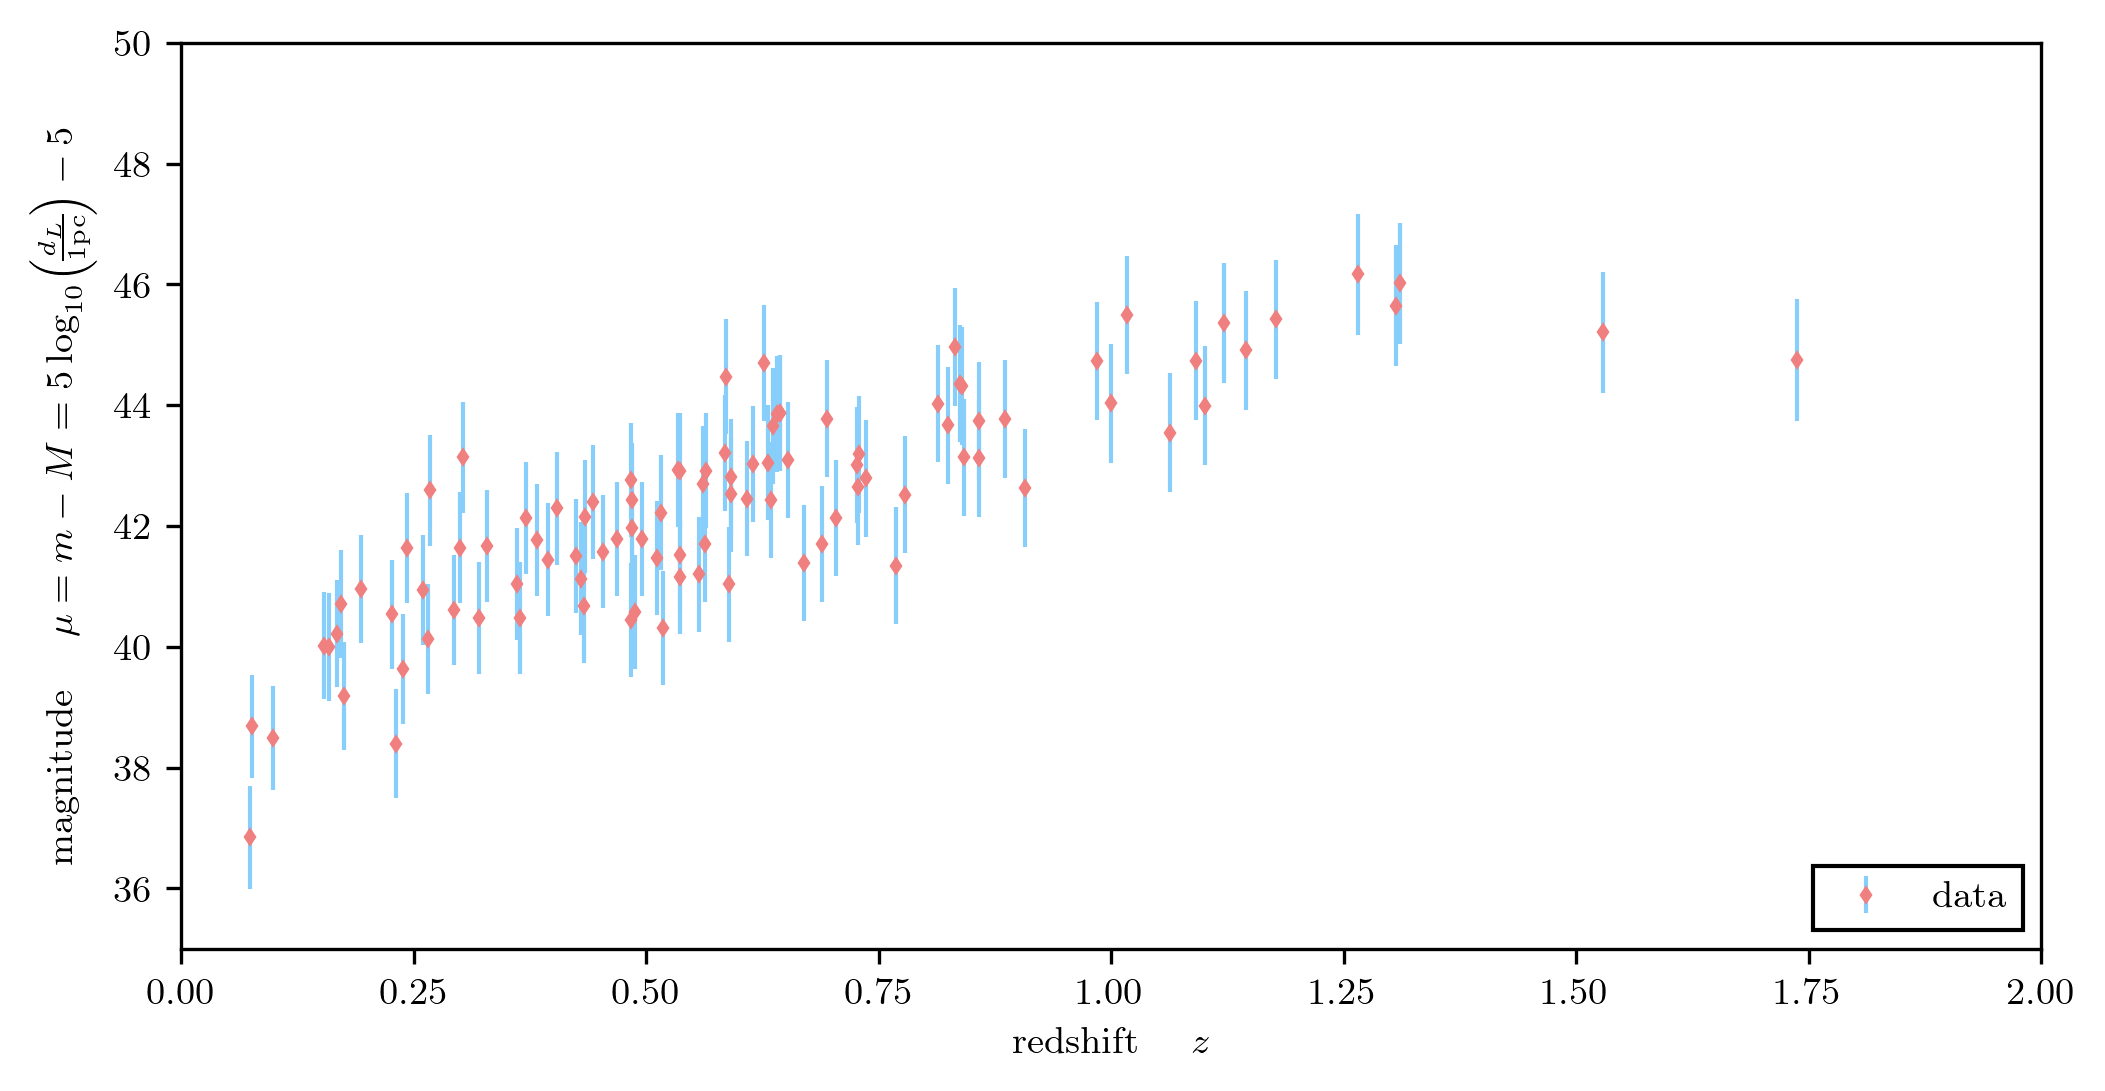

In [10]:
#-------------------------------------------------------------------------
# Generate data
#-------------------------------------------------------------------------

z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234)

fig , ax = plt.subplots(figsize=(8,4))

plt.errorbar(z_sample, mu_sample, dmu, color='lightcoral', marker='d', markersize=2, ecolor='lightskyblue', ls='', lw=1, label='data')
plt.xlabel(r"redshift $\quad z$")
plt.ylabel(r"magnitude $\quad \mu = m - M = 5 \log_{10}\!\left(\!\frac{d_L}{\rm 1 pc}\!\right) - 5$")
plt.xlim(0,2)
plt.ylim(35,50)

ax.legend(loc=4, frameon=True, framealpha=1, fancybox=False, edgecolor='black' )


#-------------------------------------------------------------------------

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(z_sample[:,np.newaxis], mu_sample, dmu)
# theta0 = lin_reg.intercept_
# theta0, theta1 = lin_reg.coef_
# mu_pred_LR = lin_reg.predict(z_test[:,np.newaxis])

pol_degrees = range(1,11)
pol_regr = []
theta = []
mu_pred = []
for d in pol_degrees:
    pol_regr.append(PolynomialRegression(d))

[]


In [45]:
z_test = np.linspace(0,2,1000)

for i in range(10):
    pol_regr[i].fit(z_sample[:,np.newaxis], mu_sample, dmu)
    theta.append(pol_regr[i].coef_)
    mu_pred.append(pol_regr[i].predict(z_test[:,np.newaxis]))

In [83]:
color1ist = mcp.gen_color(cmap="magma",n=10)
# print(color1ist)

labels=[]
for i in range(10):
    l0 = r'$\mu(z) = \theta_0 + \theta_1 \, z'
    for j in range(1,i+1):
        n = '{:d}'.format(j+1) 
        l0 += r'+\theta_{' + n + '}\, z^{' + n + '}'
    l0 += '$'
    # print(l0)
    labels.append(l0)

print()

labels_nums=[]
for i in range(10):
    l0 = '$\mu(z) = {:.2f}'.format(theta[i][0])
    l0 += '+ {:.2f} \, z '.format(theta[i][1])
    for j in range(1,i+1):
        n = '{:d}'.format(j+1) 
        if theta[i][j]>0:
            l0 += '+{:.2f}'.format(theta[i][j]) + '\, z^{' + n + '}'
        else:
            l0 += '{:.2f}'.format(theta[i][j]) + '\, z^{' + n + '}'
    l0 += '$'
    # print(l0)
    labels_nums.append(l0)


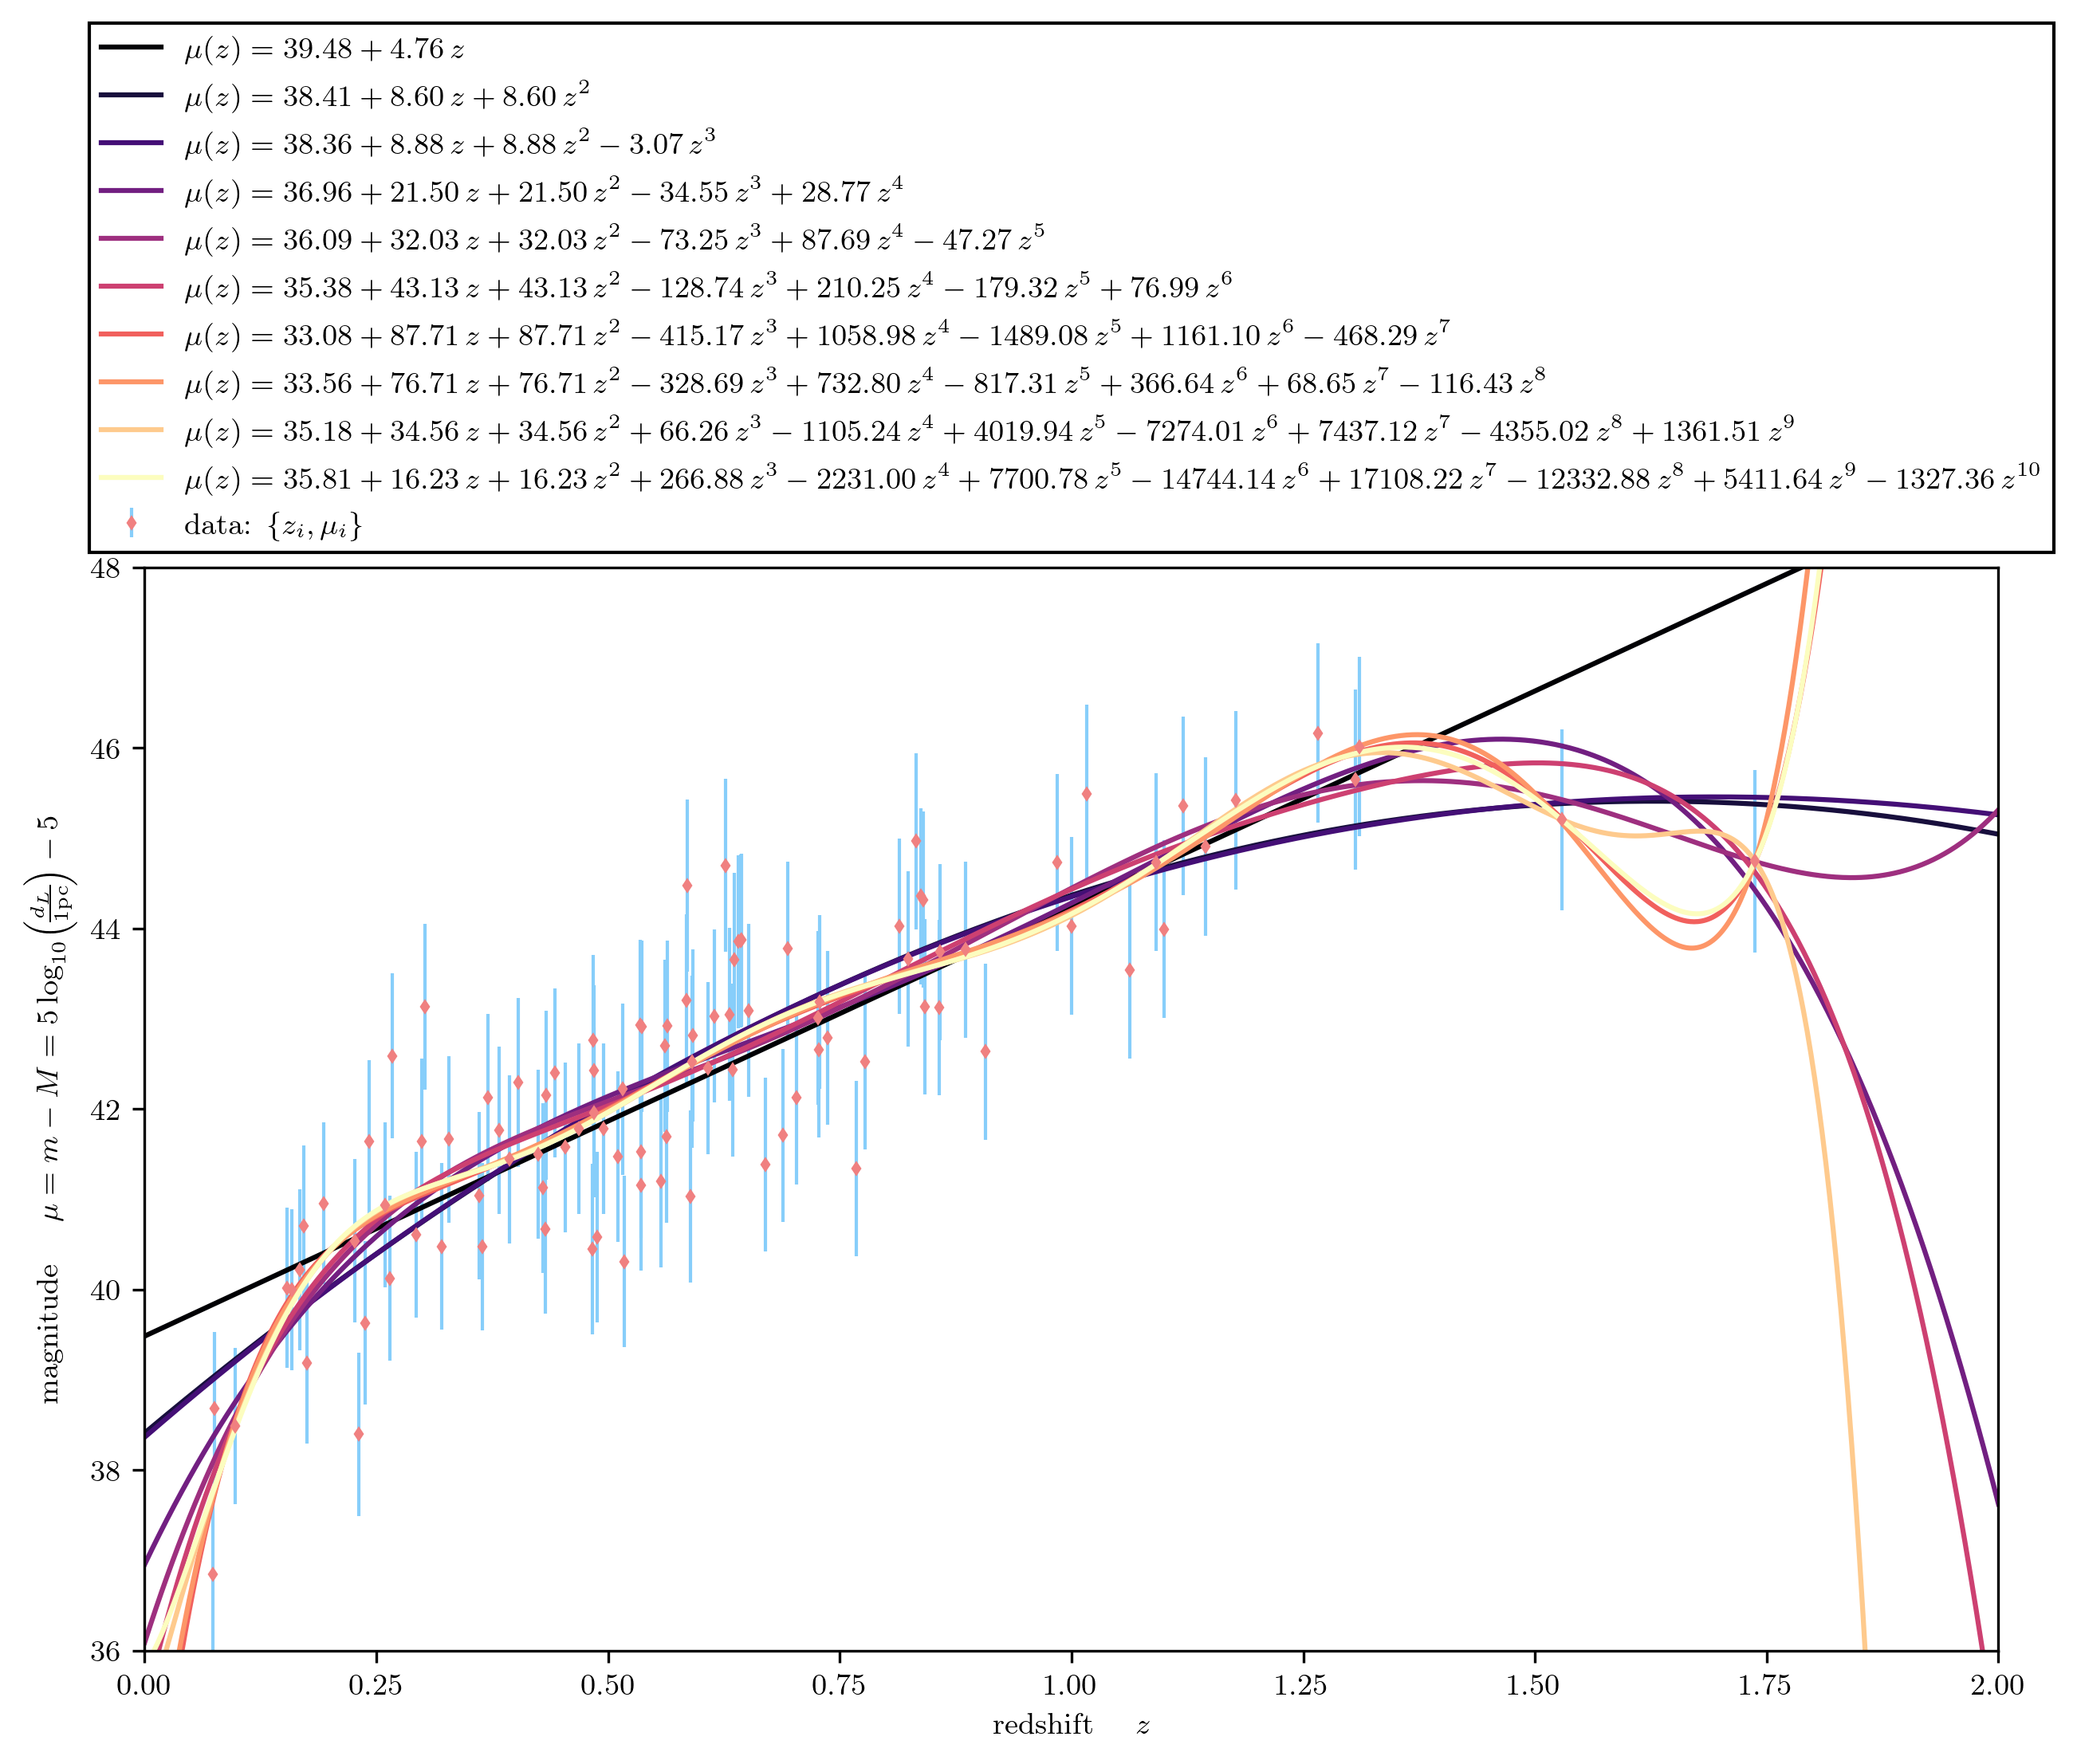

In [84]:
fig , ax = plt.subplots(figsize=(10,6))

ax.errorbar(z_sample, mu_sample, dmu, color='lightcoral', marker='d', markersize=2, ecolor='lightskyblue', ls='', lw=1, label='data: $\{z_i, \mu_i\}$')
ax.set_xlabel(r"redshift $\quad z$")
ax.set_ylabel(r"magnitude $\quad \mu = m - M = 5 \log_{10}\!\left(\!\frac{d_L}{\rm 1 pc}\!\right) - 5$")
ax.set_xlim(0,2)
ax.set_ylim(36,48)

for i in range(10):
    ax.plot(z_test, mu_pred[i], color=color1ist[i] , label=labels_nums[i])   #, color='khaki', alpha=1-i/(12)

_ = ax.legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc='lower center',bbox_to_anchor=(0.5,1.0)) #,bbox_to_anchor=(0.75,0))


I guesstimate that the quadratic or cubic model have provided the best results, that I'm underfitting with the linear model, and overfitting with all other models except quadratic and cubic.